# Interpolating FVCOM Data onto a Regular Grid

This tutorial demonstrates how to interpolate FVCOM model output onto a regular longitude/latitude grid (or any arbitrary set of coordinates) using PyFVCOM2. This is useful for:

- Comparing FVCOM output with observations or other models on a structured grid
- Creating gridded products from unstructured FVCOM output
- Extracting data at specific locations of interest

## Overview

FVCOM uses an unstructured triangular mesh, which makes direct comparison with gridded datasets difficult. PyFVCOM2 provides interpolation tools that allow you to map FVCOM variables onto any set of target coordinates — whether that's a regular lon/lat grid, a transect, or a sparse set of observation points.

The key steps are:
1. Load FVCOM output using `FVCOMReader`
2. Define target interpolation coordinates (horizontal, vertical, and temporal)
3. Use `FVCOMInterpolator` to interpolate the desired variables
4. Visualise the results

## Prerequisites

Before running this tutorial, ensure you have:
- FVCOM output files in NetCDF format
- The PyFVCOM2 package installed
- Cartopy installed (for map projections in the plots)

## Step 1: Import Required Libraries

We begin by importing the necessary modules:

In [1]:
from collections import namedtuple
import pathlib
import os
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pyfvcom2.fvcom_reader import FVCOMReader
from pyfvcom2.interpolation import InterpolationCoordinates, FVCOMInterpolator
from pyfvcom2.coordinates import utm_from_lonlat
from pyfvcom2.plotting import create_figure

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## Step 2: Load FVCOM Output

Set the path to your FVCOM output files and create a reader object. `FVCOMReader` accepts a list of NetCDF files, which it treats as a single continuous dataset.

In [2]:
# Set paths to FVCOM data
data_dir = os.path.expanduser('~/data/pyfvcom2_doc')
fvcom_data_dir = f'{data_dir}/FVCOM_tamar_estuary'
fvcom_file_stem = 'fvcom_tamar_estuary_000'
fvcom_file_list = sorted(glob(f'{fvcom_data_dir}/{fvcom_file_stem}*.nc'))

# Initialise FVCOM reader
fvcom_reader = FVCOMReader(fvcom_file_list)

# Initialise FVCOM interpolator
interpolator = FVCOMInterpolator(fvcom_reader)

Accessing FVCOM metadata from: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/fvcom_tamar_estuary_0001.nc


## Step 3: Define the Target Grid

We'll create a regular longitude/latitude grid that spans the FVCOM domain. The grid limits are taken directly from the FVCOM mesh, and we specify the resolution as points per degree.

Note: the target coordinates don't have to be a regular grid — you could supply any set of lon/lat points (e.g. observation stations, a transect, or a scattered set of locations).

In [3]:
# Named tuple for the grid limits
GridLims = namedtuple('GridLims', ('lon_min', 'lon_max', 'lat_min', 'lat_max'))


def get_lons_lats(grid_lims, points_per_degree):
    """ Helper function for generating lat and lon grids.

    Parameters
    ----------
    grid_lims : GridLims
        Named tuple giving the grid limits.
    points_per_degree : int
        The number of points per degree longitude and latitude.

    Returns
    -------
    lon, lat : NDArray
        1D lon and lat arrays for the new grid.
    """
    n_lon = int((grid_lims.lon_max - grid_lims.lon_min) * points_per_degree)
    n_lat = int((grid_lims.lat_max - grid_lims.lat_min) * points_per_degree)
    lon = np.linspace(grid_lims.lon_min, grid_lims.lon_max, n_lon, dtype=float)
    lat = np.linspace(grid_lims.lat_min, grid_lims.lat_max, n_lat, dtype=float)
    return lon, lat


# Get grid limits from the FVCOM mesh
lon_min = fvcom_reader.grid.lon.min()
lon_max = fvcom_reader.grid.lon.max()
lat_min = fvcom_reader.grid.lat.min()
lat_max = fvcom_reader.grid.lat.max()
grid_lims = GridLims(lon_min, lon_max, lat_min, lat_max)

# Grid resolution
points_per_degree = 72

# Generate the 1D lon and lat arrays
lon, lat = get_lons_lats(grid_lims, points_per_degree)

# Create 2D lon/lat grids, then flatten to 1D arrays for InterpolationCoordinates
lon_2D, lat_2D = np.meshgrid(lon, lat, indexing='ij')
lon_flat = lon_2D.flatten()
lat_flat = lat_2D.flatten()

n_horizontal_points = lon_flat.size
print(f'Number of horizontal interpolation points: {n_horizontal_points}')

Number of horizontal interpolation points: 4104


## Step 4: Define the Vertical and Temporal Coordinates

For 3D variables (e.g. temperature, salinity, velocity), we also need to specify the target depth levels. Here we create a uniform depth grid spanning from the surface to the maximum bathymetric depth in the FVCOM domain.

The depths array is 2D with shape `(n_depths, n_horizontal_points)`, allowing different depth levels at each horizontal point if desired. For a uniform grid, we simply repeat the same depth column at every point.

We also select a subset of time steps (4!) from the FVCOM output to interpolate.

In [4]:
# Define a depth grid from the surface to the maximum FVCOM depth
depth_surface = 0.0
depth_bottom = fvcom_reader.grid.bathy_nodes.max()
n_depths = 10
depths = np.linspace(depth_surface, -depth_bottom, n_depths, dtype=float)

print(f'Depth levels (m): {depths}')

# Create a 2D depths array (n_depths, n_horizontal_points)
depths_2D = np.repeat(depths[:, np.newaxis], n_horizontal_points, axis=1)

# Select dates for interpolation — here we use the first 12 time steps
dates = fvcom_reader.dates[:4]
print(f'Interpolation dates: {dates[0]} to {dates[-1]}')

Depth levels (m): [  0.          -8.92703533 -17.85407066 -26.78110504 -35.70814133
 -44.63517761 -53.56221008 -62.48924637 -71.41628265 -80.34331512]
Interpolation dates: 2020-04-30 00:00:00 to 2020-04-30 03:00:00


## Step 5: Create Interpolation Coordinates

Bundle the horizontal, vertical, and temporal coordinates into an `InterpolationCoordinates` object. This tells the interpolator where to evaluate the FVCOM fields.

- `x1`: longitudes (or x in a projected coordinate system)
- `x2`: latitudes (or y in a projected coordinate system)
- `x3`: depths, with shape `(n_depths, n_horizontal_points)`
- `dates`: the target times
- `horizontal_coordinate_system`: `'geographic'` for lon/lat, or `'cartesian'` for projected coordinates
- `vertical_coordinate_system`: `'z'` for depth in metres

Instead of interpolating in vertical z coordinates, it is also possible to interpolate directly onto sigma levels (option 'sigma'). This is likely to be most useful when interpolating from one FVCOM grid to another, especially when there is a need to extrapolate beyond the limits of the original grid.

In [5]:
interp_coords = InterpolationCoordinates(
    dates=np.asarray(dates),
    x3=depths_2D,
    x2=lat_flat,
    x1=lon_flat,
    horizontal_coordinate_system='geographic',
    vertical_coordinate_system='z',
)

## Step 6: Interpolate FVCOM Variables

Now we interpolate the desired FVCOM variables onto the target coordinates. The variable names used here are the standard FVCOM NetCDF variable names:

| Variable | Description | Dimensions |
|----------|-------------|------------|
| `h` | Bathymetric depth | 2D (static) |
| `zeta` | Sea surface elevation | 2D + time |
| `temp` | Temperature | 3D + time |
| `salinity` | Salinity | 3D + time |
| `u` | Eastward velocity | 3D + time |
| `v` | Northward velocity | 3D + time |

The `extrapolate_horizontally` option controls whether values are extrapolated to points outside the FVCOM domain. Separate options exist for extrapolating upwards and downwards. Here we don't try to extrapolate beyond the limits of the grid.

In [6]:
fvcom_var_names = ['h', 'zeta', 'temp', 'salinity', 'u', 'v']

var_data = {}
for fvcom_var_name in fvcom_var_names:
    print(f'Interpolating: {fvcom_var_name}')
    var_data[fvcom_var_name] = interpolator.interpolate(
        interp_coords, fvcom_var_name, extrapolate_horizontally=False
    )

Interpolating: h
Interpolating: zeta
Interpolating FVCOM zeta to FVCOM grid for date: 2020-04-30 00:00:00.
Interpolating FVCOM zeta to FVCOM grid for date: 2020-04-30 01:00:00.
Interpolating FVCOM zeta to FVCOM grid for date: 2020-04-30 02:00:00.
Interpolating FVCOM zeta to FVCOM grid for date: 2020-04-30 03:00:00.
Interpolating: temp
Interpolating FVCOM temp for date: 2020-04-30 00:00:00.
Interpolating FVCOM temp for date: 2020-04-30 01:00:00.
Interpolating FVCOM temp for date: 2020-04-30 02:00:00.
Interpolating FVCOM temp for date: 2020-04-30 03:00:00.
Interpolating: salinity
Interpolating FVCOM salinity for date: 2020-04-30 00:00:00.
Interpolating FVCOM salinity for date: 2020-04-30 01:00:00.
Interpolating FVCOM salinity for date: 2020-04-30 02:00:00.
Interpolating FVCOM salinity for date: 2020-04-30 03:00:00.
Interpolating: u
Interpolating FVCOM u for date: 2020-04-30 00:00:00.
Interpolating FVCOM u for date: 2020-04-30 01:00:00.
Interpolating FVCOM u for date: 2020-04-30 02:00:00.

## Step 7: Visualise the Results

### Bathymetry

Bathymetry (`h`) is a static 2D field — it has no time or depth dimension.

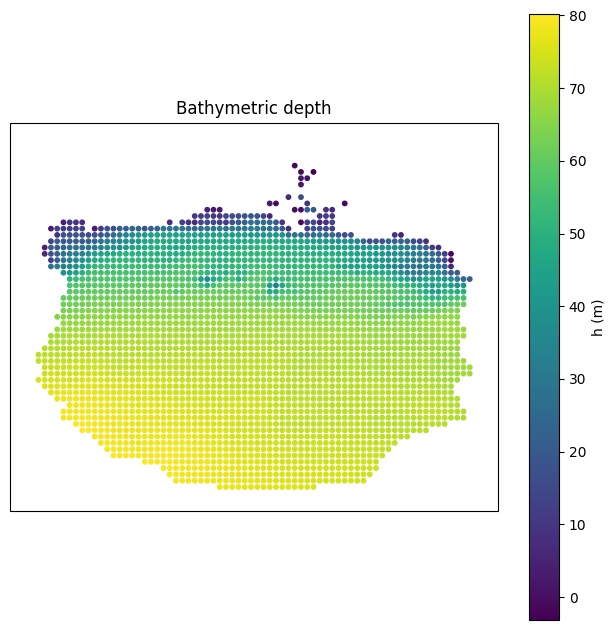

In [7]:
fig, ax = create_figure((20, 20), projection=ccrs.PlateCarree())
sc = ax.scatter(interp_coords.x1, interp_coords.x2, c=var_data['h'][:], s=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('h (m)')
ax.set_title('Bathymetric depth')
plt.show()

### Sea Surface Elevation

Sea surface elevation (`zeta`) varies in time but has no depth dimension. Here we plot the first time step.

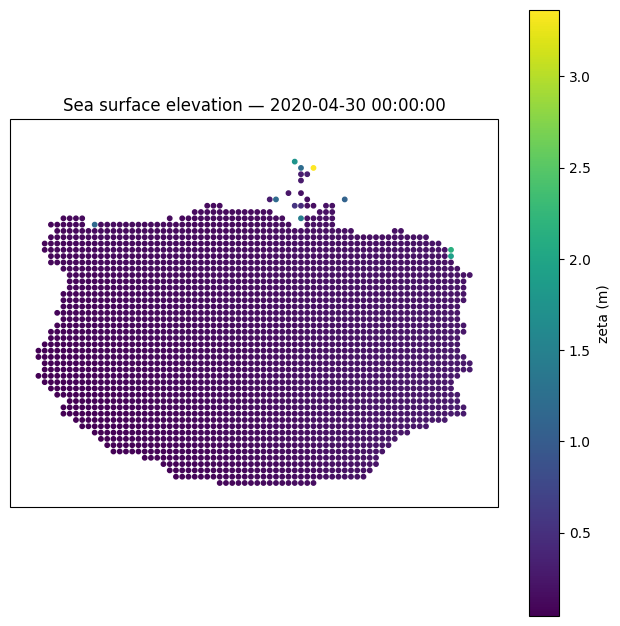

In [8]:
t_idx = 0

fig, ax = create_figure((20, 20), projection=ccrs.PlateCarree())
sc = ax.scatter(interp_coords.x1, interp_coords.x2, c=var_data['zeta'][t_idx, :], s=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('zeta (m)')
ax.set_title(f'Sea surface elevation — {dates[t_idx]}')
plt.show()

### 3D Variables (Temperature, Salinity, Velocity)

3D variables have dimensions `(time, depth, horizontal_points)`. Here we plot the surface layer (depth index 0) at the first time step for temperature, salinity, and the velocity components. Note fewer points are shaded compared with the `h` and `zeta` plots. This is because these cells are dry at this time, and are thus masked - FVCOM flags a cell as being dry when zeta falls below `h` plus 0.2 m. The 0.2 m acts to maintain a minimum water depth of 0.2 m. As the water level hits this point, the cell is flagged as being dry, and `zeta` is held at that level until it floods again. Also note that when vertical_coordinate_system is set to `sigma`, no masking occurs - PyFVCOM2 will readily interpolate onto dry points as long as they are inside the domain (or outside, if extrpolation is permitted). This can be helpful when creating initial conditions for FVCOM when the new domain has some areas that lie outside of the original domain (e.g., the new domain resolves an estuary which the original domain does not).

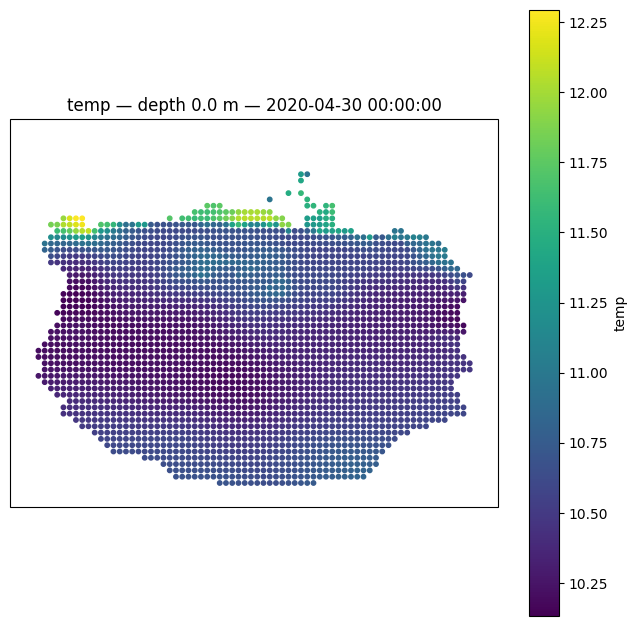

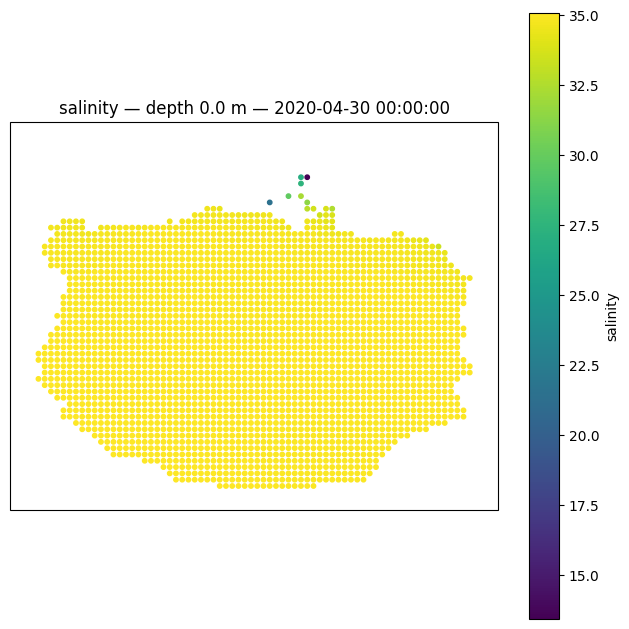

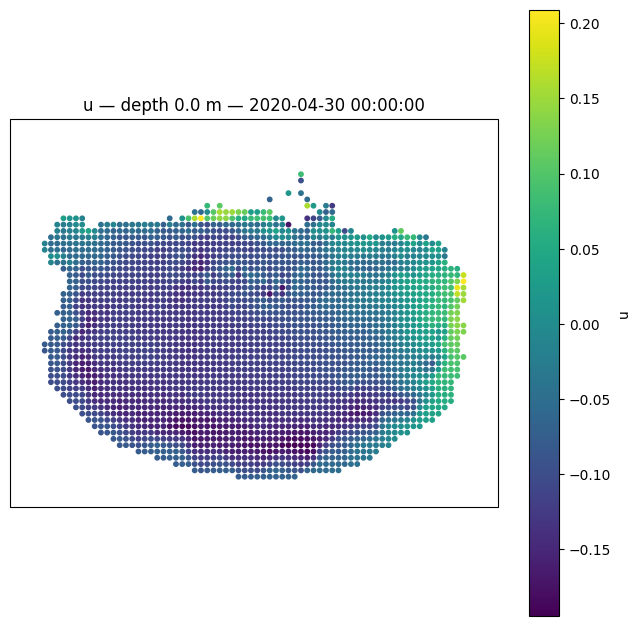

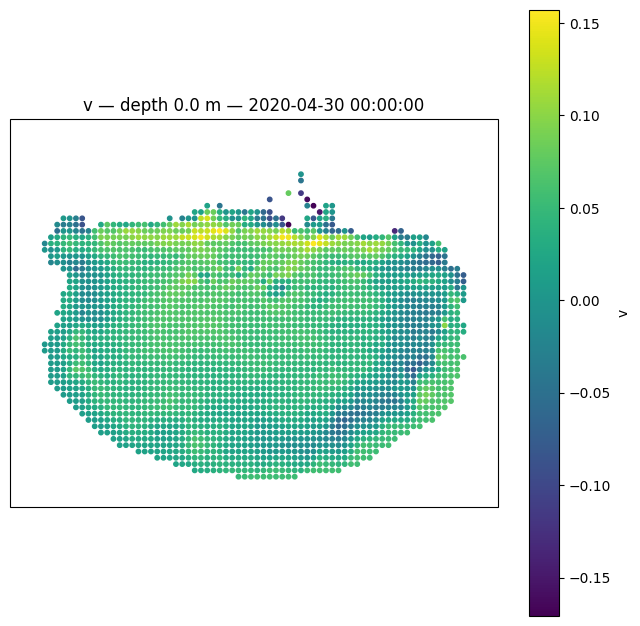

In [9]:
t_idx = 0
depth_idx = 0

for fvcom_var_name in ['temp', 'salinity', 'u', 'v']:
    fig, ax = create_figure((20, 20), projection=ccrs.PlateCarree())
    sc = ax.scatter(
        interp_coords.x1, interp_coords.x2,
        c=var_data[fvcom_var_name][t_idx, depth_idx, :], s=10,
    )
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(fvcom_var_name)
    ax.set_title(f'{fvcom_var_name} — depth {depths[depth_idx]:.1f} m — {dates[t_idx]}')
    plt.show()